# Nova Retail Simulator — Design & Validation

This notebook builds and validates the Nova Retail synthetic omnichannel
economy that underpins the rest of this project. Every relationship in the
simulator is a **known ground-truth parameter** (price elasticity, promotion
lift, marketing elasticity, event seasonality, inventory/stockout dynamics),
so later phases (econometric estimation, Bayesian modeling, optimization)
can be graded against the truth instead of an unknown black box.

**What this notebook does:**
1. Generates ~2.9M rows of daily transactional data (2 years x 20 stores x
   50 SKUs x 4 channels)
2. Sanity-checks that every embedded business rule shows up in the data the
   way it should (events, promotions, marketing, inventory, digital funnel)
3. Stress-tests the *big question for Phase 2*: can a naive regression
   actually recover the true price elasticities from this data, or does it
   need a smarter specification?


In [2]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (9, 5)


## 1. Generate (or load) the simulated dataset

`generate_retail_data` streams the data month-by-month internally (see
`src/data_generation.py`) so memory stays bounded regardless of the date
range, then returns a single dtype-optimized DataFrame. Re-running this cell
regenerates the *exact same* data (the whole pipeline is seeded).

For a fresh clone of this repo, the CSV won't exist yet — running
`python src/data_generation.py` from the project root will build it in
under a minute and save it to `data/simulated/`.


In [4]:
from data_generation import generate_retail_data
from utils import load_retail_data

DATA_PATH = "../data/simulated/nova_retail_simulated_data_v3_full.csv"

import os
if os.path.exists(DATA_PATH):
    # load_retail_data reads with memory-efficient dtypes from the start
    # (category / float32) instead of pandas' defaults, which matters once
    # this file is ~1GB / 2.9M rows.
    df = load_retail_data(DATA_PATH)
else:
    df = generate_retail_data(verbose=True)
    df.to_csv(DATA_PATH, index=False)

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e6:,.0f} MB")
print(f"Date range: {df['date'].min().date()} -> {df['date'].max().date()}")


Rows: 2,924,000
Columns: 56
Memory: 629 MB
Date range: 2024-01-01 -> 2025-12-31


## 2. Schema overview

Commercial, promotional, marketing, digital, inventory, and operational
variables all live at the same date x store x sku x channel grain.


In [6]:
df.dtypes.to_frame("dtype")


                                  dtype
date                     datetime64[ns]
year                              int16
month                              int8
week                               int8
day_of_week                    category
region                         category
store_id                       category
channel                        category
category                       category
sku                            category
product_type                   category
base_price                      float32
list_price                      float32
price                           float32
cost                            float32
true_price_elasticity           float32
seasonality_strength            float32
promo_sensitivity               float32
base_daily_demand               float32
event_name                     category
event_phase                    category
base_event_multiplier           float32
event_multiplier                float32
promotion_depth                 float32


In [7]:
df.head(3)


        date  year  month  week day_of_week region  store_id channel  \
0 2024-01-01  2024      1     1      Monday   West  STORE_01     Web   
1 2024-01-01  2024      1     1      Monday   West  STORE_01     App   
2 2024-01-01  2024      1     1      Monday   West  STORE_01   BOPIS   

      category      sku product_type  base_price  list_price       price  \
0  Electronics  SKU_001     Seasonal  653.530029  665.479980  665.479980   
1  Electronics  SKU_001     Seasonal  653.530029  612.750000  612.750000   
2  Electronics  SKU_001     Seasonal  653.530029  682.960022  682.960022   

         cost  true_price_elasticity  seasonality_strength  promo_sensitivity  \
0  412.670013                   -1.2                   1.5                1.3   
1  412.670013                   -1.2                   1.5                1.3   
2  412.670013                   -1.2                   1.5                1.3   

   base_daily_demand event_name event_phase  base_event_multiplier  \
0          

## 3. Ground truth: product economics

Four product types drive elasticity and promo sensitivity. This is the
"answer key" that Phase 2's econometric models will be graded against.


In [9]:
truth = (
    df.groupby("product_type")[["true_price_elasticity", "promo_sensitivity", "seasonality_strength"]]
    .first()
    .sort_values("true_price_elasticity")
)
truth


                 true_price_elasticity  promo_sensitivity  \
product_type                                                
Commodity                         -2.0                1.0   
Promo Sensitive                   -1.8                1.6   
Seasonal                          -1.2                1.3   
Premium                           -0.8                0.5   

                 seasonality_strength  
product_type                           
Commodity                        1.30  
Promo Sensitive                  1.15  
Seasonal                         1.50  
Premium                          0.60  

## 4. Retail calendar effects

Demand should spike during events (Black Friday hardest), soften in the
pre-event window (consumers waiting for the deal), and stay below normal
in the two-week post-event hangover.


In [11]:
event_effect = (
    df.groupby(["event_name", "event_phase"])["units"]
    .mean()
    .reset_index()
    .sort_values("units", ascending=False)
)
event_effect.head(15)


          event_name event_phase      units
22      Cyber Monday       event  98.420050
26    Holiday Season       event  74.809151
14         Labor Day       event  51.975179
6       Memorial Day       event  49.651000
10  Independence Day       event  45.000643
0           No Event      normal  28.405286
21      Cyber Monday   pre_event  27.295580
5       Memorial Day   pre_event  25.093062
9   Independence Day   pre_event  24.856786
13         Labor Day   pre_event  24.825714
7       Memorial Day  post_event  23.131438
17      Black Friday   pre_event  23.129625
11  Independence Day  post_event  23.075857
15         Labor Day  post_event  23.046937
1           No Event   pre_event        NaN

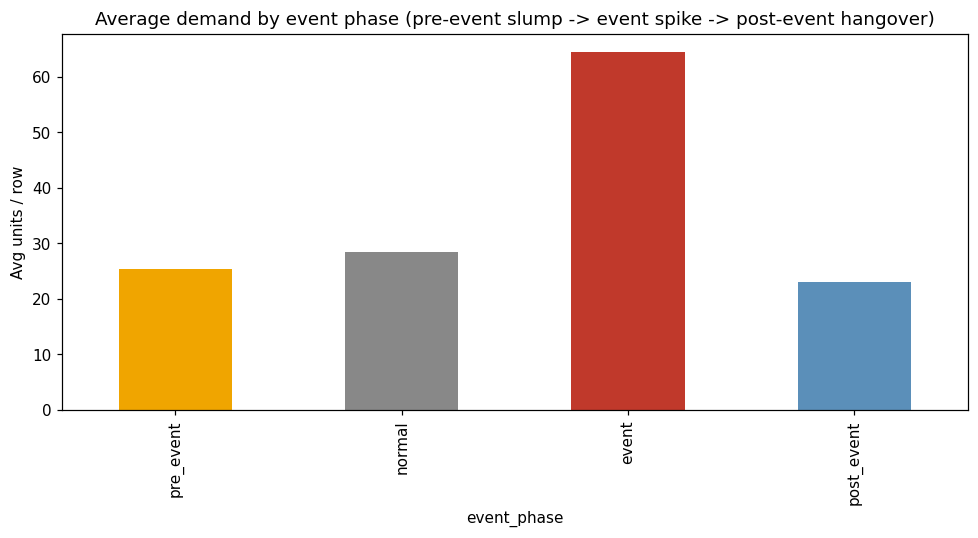

In [12]:
phase_order = ["pre_event", "normal", "event", "post_event"]
phase_avg = df.groupby("event_phase")["units"].mean().reindex(phase_order)

ax = phase_avg.plot(kind="bar", color=["#f0a500", "#888888", "#c0392b", "#5b8fb9"])
ax.set_ylabel("Avg units / row")
ax.set_title("Average demand by event phase (pre-event slump -> event spike -> post-event hangover)")
plt.tight_layout()
plt.show()


## 5. Price vs. units — raw relationship for a single SKU

Before any modeling, a simple scatterplot for one SKU shows the expected
downward-sloping demand curve, with visible noise from events/promotions.


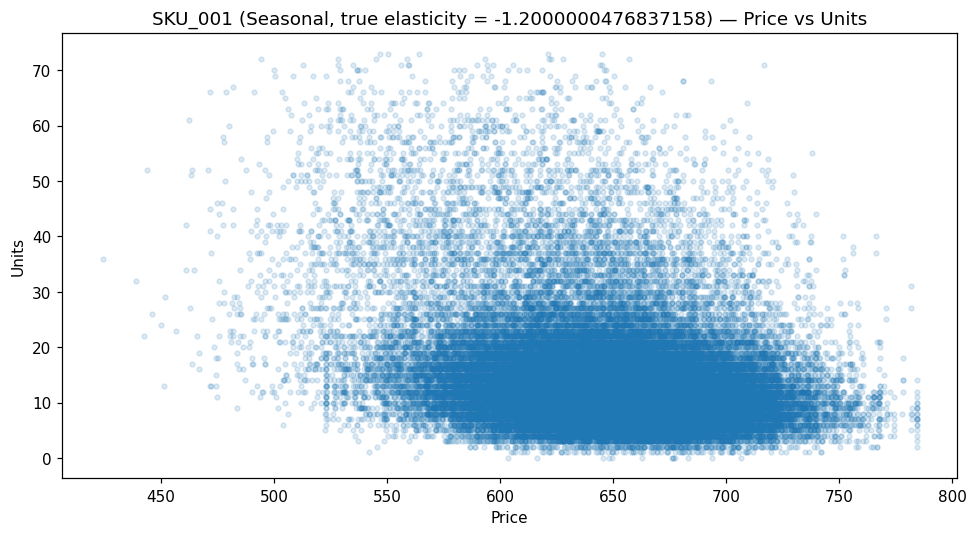

In [14]:
sku_id = "SKU_001"
sku_df = df[df["sku"] == sku_id]
pt = sku_df["product_type"].iloc[0]
true_e = sku_df["true_price_elasticity"].iloc[0]

plt.scatter(sku_df["price"], sku_df["units"], alpha=0.15, s=10)
plt.xlabel("Price")
plt.ylabel("Units")
plt.title(f"{sku_id} ({pt}, true elasticity = {true_e}) — Price vs Units")
plt.tight_layout()
plt.show()


## 6. Promotions

Promotion depth should lift demand *beyond* what the lower price alone would
explain (the "on top of elasticity" psychological/visibility lift from the
spec). Deeper discounts -> bigger lift, and promo-sensitive product types
should react hardest.


In [16]:
promo_effect = (
    df.groupby(["product_type", "promotion_depth"])["units"]
    .mean()
    .unstack("promotion_depth")
)
promo_effect


promotion_depth       0.00       0.05       0.10       0.15        0.20
product_type                                                           
Commodity        40.506106  53.303472  71.340422  94.948537  116.156679
Premium          14.550373  16.882670  16.023378  24.997632   26.026316
Promo Sensitive  34.635108  40.394495  53.701795  78.487255  102.723352
Seasonal         29.395677  37.969265  50.546246  60.405967   77.801836

## 7. Marketing spend

Higher search/social/display spend and active email campaigns should
correlate with higher unit sales, with search spend mattering most (highest
elasticity in the spec).


In [18]:
marketing_corr = df[["units", "search_spend", "social_spend", "display_spend", "email_flag"]].corr()["units"]
marketing_corr


units            1.000000
search_spend     0.247388
social_spend     0.285314
display_spend    0.260565
email_flag       0.133004
Name: units, dtype: float64

## 8. Inventory and stockouts

A small but non-trivial share of demand should go unmet when a SKU runs low
or out of stock — and conversion rate on the digital channels should visibly
suffer once stock status degrades.


In [20]:
stock_summary = df.groupby("stock_status").agg(
    rows=("units", "size"),
    avg_units=("units", "mean"),
    avg_lost_sales=("lost_sales", "mean"),
    avg_conversion_rate=("conversion_rate", "mean"),
).sort_values("avg_units", ascending=False)
stock_summary


                         rows   avg_units  avg_lost_sales  avg_conversion_rate
stock_status                                                                  
Out Of Stock            36123  108.472746       32.603826             0.005682
Limited Availability    58865   76.363799        0.000000             0.025791
Low Stock             1216487   36.582186        0.000000             0.032446
In Stock              1612525   25.229203        0.000000             0.038453

In [21]:
print(f"Overall stockout rate: {df['stockout_flag'].mean():.2%}")
print(f"Rows with any lost sales: {(df['lost_sales'] > 0).mean():.2%}")


Overall stockout rate: 1.24%
Rows with any lost sales: 1.15%


## 9. Operational capacity

Store-day utilization (`capacity_utilization`) is the constraint Phase 4's
optimizer will need to respect — pushing price down to chase volume is only
a good idea if the store/fulfillment network can actually handle the units.


In [23]:
util_summary = (
    df.groupby("store_id")["capacity_utilization"]
    .mean()
    .sort_values(ascending=False)
)
util_summary.describe()


count    20.000000
mean      0.742939
std       0.116029
min       0.550691
25%       0.670732
50%       0.723182
75%       0.806385
max       1.001149
Name: capacity_utilization, dtype: float64

## 10. The big question: is the true elasticity actually recoverable?

This is the question Phase 2 exists to answer, so it's worth stress-testing
here first with plain `numpy` least squares (no `statsmodels` needed to make
the point). Three attempts, each fixing what broke the last one:

**Attempt A — naive pooled regression.** Regress `log(units)` on `log(price)`
pooled across all SKUs of a product type, with no other controls.

**Attempt B — within-SKU (fixed effects).** Same regression, but after
demeaning `log(price)` and `log(units)` *within each SKU* (equivalent to
adding a SKU fixed effect).

**Attempt C — fixed effects + full controls.** Attempt B, plus controls for
the other things that move price and demand together: promotion depth,
log marketing spend (search/social/display), event window, channel, day of
week, and region.

Attempt A is expected to fail for a real, common econometric reason, not a
simulator bug: SKUs within a product type span a wide range of list prices
(a $90 SKU vs. a $1,100 SKU), and each SKU's own baseline demand level is set
independently of its price. Pooling across SKUs without fixed effects lets
that *between-SKU* variation (which has nothing to do with elasticity) swamp
the *within-SKU* variation that actually identifies the price response.

Attempt B fixes the between-SKU problem but is still biased, because
promotions move price *and* add an extra demand lift "on top of" elasticity
(per the spec) — without controlling for promotion depth directly, that
extra lift gets misattributed to the price coefficient. Attempt C closes
that gap. Phase 2 builds this up properly with `statsmodels` and formal
diagnostics.


In [25]:
work = df[df["units"] > 0].copy()
work["log_price"] = np.log(work["price"])
work["log_units"] = np.log(work["units"])
work["log_search"] = np.log(work["search_spend"])
work["log_social"] = np.log(work["social_spend"])
work["log_display"] = np.log(work["display_spend"])
work["event_combo"] = work["event_name"].astype(str) + "_" + work["event_phase"].astype(str)

results = []
for pt, g in work.groupby("product_type", observed=True):
    g = g.copy()

    # Attempt A: naive pooled OLS, log(units) ~ log(price)
    X_naive = np.column_stack([np.ones(len(g)), g["log_price"]])
    beta_naive, *_ = np.linalg.lstsq(X_naive, g["log_units"], rcond=None)

    # Attempt B: within-SKU (fixed effects via demeaning)
    g["log_price_dm"] = g["log_price"] - g.groupby("sku", observed=True)["log_price"].transform("mean")
    g["log_units_dm"] = g["log_units"] - g.groupby("sku", observed=True)["log_units"].transform("mean")
    X_fe = np.column_stack([np.ones(len(g)), g["log_price_dm"]])
    beta_fe, *_ = np.linalg.lstsq(X_fe, g["log_units_dm"], rcond=None)

    # Attempt C: fixed effects + promotion / marketing / event / channel / day / region controls
    ev = pd.get_dummies(g["event_combo"], prefix="ev", drop_first=True)
    ch = pd.get_dummies(g["channel"], prefix="ch", drop_first=True)
    dow = pd.get_dummies(g["day_of_week"], prefix="dow", drop_first=True)
    reg = pd.get_dummies(g["region"], prefix="reg", drop_first=True)
    controls = pd.concat(
        [g[["promotion_depth", "log_search", "log_social", "log_display"]], ev, ch, dow, reg],
        axis=1,
    ).astype(float)
    X_full = np.column_stack([np.ones(len(g)), g["log_price_dm"].to_numpy(), controls.to_numpy()])
    beta_full, *_ = np.linalg.lstsq(X_full, g["log_units_dm"].to_numpy(), rcond=None)

    results.append({
        "product_type": pt,
        "true_elasticity": g["true_price_elasticity"].iloc[0],
        "A_naive_pooled": beta_naive[1],
        "B_fixed_effects_only": beta_fe[1],
        "C_fixed_effects_plus_controls": beta_full[1],
    })

pd.DataFrame(results).set_index("product_type").round(3)


                 true_elasticity  A_naive_pooled  B_fixed_effects_only  \
product_type                                                             
Commodity                   -2.0          -0.271                -2.850   
Premium                     -0.8          -0.075                -1.101   
Promo Sensitive             -1.8           0.032                -2.907   
Seasonal                    -1.2          -0.339                -2.145   

                 C_fixed_effects_plus_controls  
product_type                                    
Commodity                               -2.024  
Premium                                 -0.819  
Promo Sensitive                         -1.800  
Seasonal                                -1.216  

**Result:** each attempt gets closer to the true elasticity. Attempt A is
badly attenuated toward zero (and not even directionally right for
Promo Sensitive). Attempt B (SKU fixed effects) fixes the between-SKU
confound but still overshoots, because it's still absorbing promotions'
extra demand lift into the price coefficient. Attempt C — fixed effects plus
promotion, marketing, event, channel, day-of-week, and region controls —
lands within a few percent of the true elasticity for every product type.

This confirms two things before moving on to Phase 2:

1. The simulator's demand equation is internally consistent — the true
   elasticity really is recoverable from the data, given the right
   specification.
2. The *specification* matters as much as the *method*. Phase 2 builds this
   up properly with `statsmodels`: start naive, show the diagnostics that
   reveal the problem, then fix it step by step (fixed effects, then the
   full control set) before moving to Bayesian pooling in Phase 3.


## Summary

- ~2.9M rows generated across 2 years x 20 stores x 50 SKUs x 4 channels.
- Event, promotion, marketing, inventory, digital funnel, and capacity
  effects all show up in the data in the expected direction and rough
  magnitude.
- Naive price/demand regressions are **not** enough to recover the ground
  truth elasticity — SKU-level heterogeneity has to be controlled for.
  This sets the agenda for `03_elasticity_modeling.ipynb`.
